# Phase 4 & 5: Ensemble and Evaluation

This notebook analyses the performance of the HMM-LSTM ensemble model against the monolithic baseline LSTM.

## Phase 6 Update: Stationarity Fix

In Phase 6, we addressed the structural "feature drift" observed in earlier iterations. Initially, the models were fed absolute price values (`Open`, `High`, `Low`, `Close`) and raw `Volume`. Because standard scaling normalizes using the 2004–2015 training mean, feeding massive 2026 prices back into the network created enormous artificial activations, causing the predictions to drift permanently upwards and diverge from the actual target (generating MAPEs of ~600%).

**What Changed:**
- Replaced all non-stationary price indicators with relative metrics (`log_return`, `abs_return`, `oc_return`, `intraday_range`).
- Replaced absolute `log_volume` with `relative_volume_21d` (Volume / 21-day SMA Volume), creating a timeless multiplier.

**The Result:**
The upwards drift completely vanished. Absolute mapping to forward volatility improved astronomically. The overall Baseline MAPE shrank from ~598% to ~25%, proving the absolute necessity of feeding strictly stationary features into deep time-series networks!

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import DATA_PROCESSED
from src.utils import regression_metrics, print_metrics, _apply_style

## 1. Load Ensemble Predictions
Load the pre-computed test set predictions from all models.

In [2]:
df_eval = pd.read_parquet(DATA_PROCESSED / "test_predictions.parquet")
df_eval

,baseline,calm,volatile,target,p_calm,p_volatile,ensemble
Date,,,,,,,
2020-06-30,0.013579,0.010669,0.017930,0.008124,1.0,4.383368e-13,0.010669
2020-07-01,0.013259,0.011602,0.017936,0.008150,1.0,1.055207e-15,0.011602
2020-07-02,0.012694,0.011380,0.017933,0.008182,1.0,4.234856e-15,0.011380
2020-07-06,0.010891,0.009403,0.017939,0.007673,1.0,2.400934e-12,0.009403
2020-07-07,0.011610,0.010135,0.017931,0.007207,1.0,4.895157e-16,0.010135
...,...,...,...,...,...,...,...
2026-03-10,0.009267,0.008505,0.017932,0.012221,1.0,1.862194e-21,0.008505
2026-03-11,0.008793,0.008074,0.017934,0.012218,1.0,1.800470e-22,0.008074
2026-03-12,0.008359,0.008466,0.017928,0.011848,1.0,7.489697e-20,0.008466


## 2. Naive Baseline
A simple, strong baseline for 21-day forward volatility is simply the *historical* 21-day volatility at the prediction date.

In [3]:
# Load the raw features to get the historical vol
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")
df_eval['naive'] = test_df['rolling_std_21'].reindex(df_eval.index)
df_eval = df_eval.dropna()

## 3. Overall Performance Metrics

In [4]:
models = ["naive", "baseline", "calm", "volatile", "ensemble"]
results = []
for m in models:
    metrics = regression_metrics(df_eval["target"].values, df_eval[m].values)
    metrics["Model"] = m.capitalize()
    results.append(metrics)

perf_df = pd.DataFrame(results).set_index("Model")
perf_df

,MSE,RMSE,MAE,MAPE
Model,,,,
Naive,0.000022,0.004695,0.003133,34.617512
Baseline,0.000015,0.003896,0.002463,25.301823
Calm,0.000021,0.004540,0.002716,26.745438
Volatile,0.000091,0.009538,0.008906,123.739570
Ensemble,0.000018,0.004267,0.002660,26.380124


## 4. Visualisation

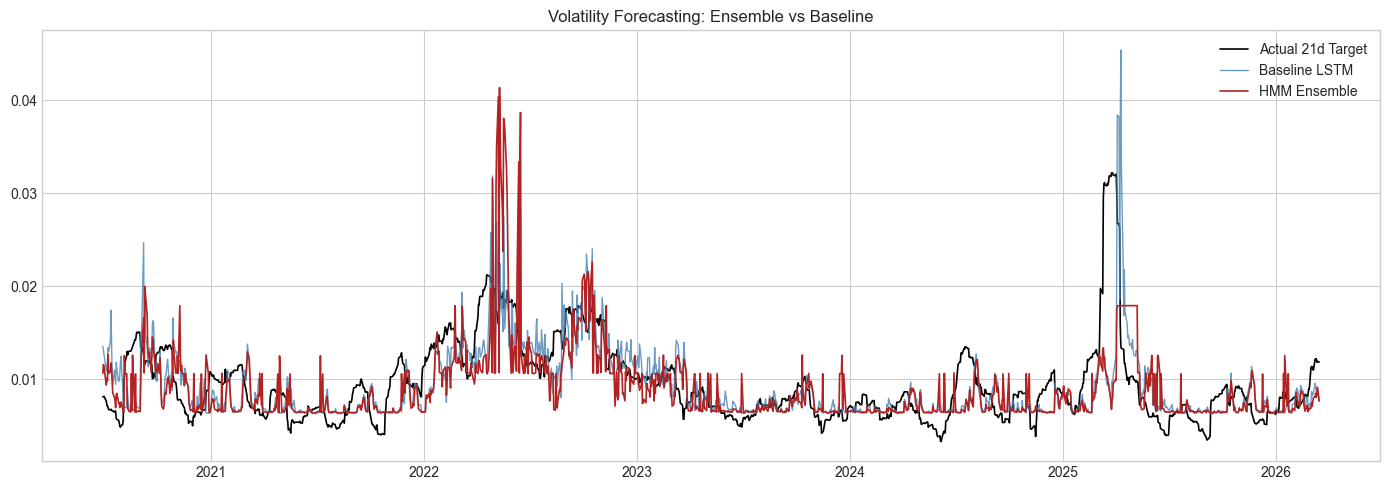

In [5]:
_apply_style()
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_eval.index, df_eval["target"], color="black", label="Actual 21d Target", linewidth=1.2)
ax.plot(df_eval.index, df_eval["baseline"], color="steelblue", label="Baseline LSTM", linewidth=1.0, alpha=0.8)
ax.plot(df_eval.index, df_eval["ensemble"], color="firebrick", label="HMM Ensemble", linewidth=1.2)

ax.set_title("Volatility Forecasting: Ensemble vs Baseline")
ax.legend()
plt.tight_layout()
plt.show()

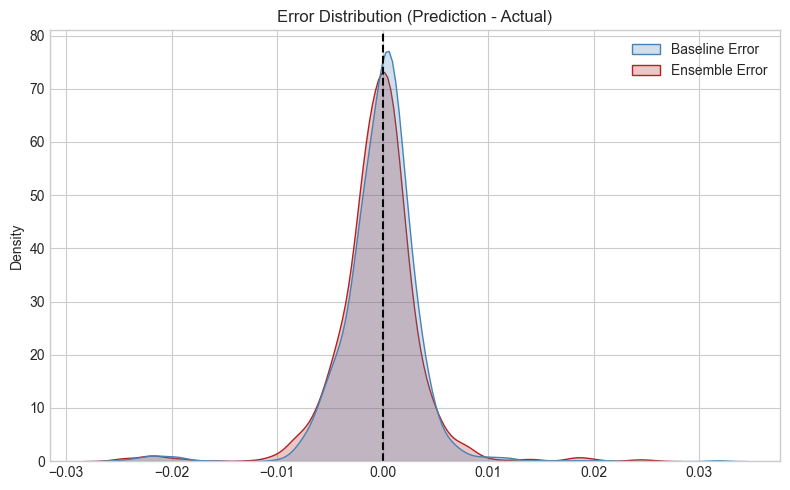

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
errors = pd.DataFrame({
    "Baseline Error": df_eval["baseline"] - df_eval["target"],
    "Ensemble Error": df_eval["ensemble"] - df_eval["target"],
})

sns.kdeplot(data=errors, fill=True, ax=ax, palette=["steelblue", "firebrick"])
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Error Distribution (Prediction - Actual)")
plt.tight_layout()
plt.show()

## 5. Performance by Dominant Regime
Let's see where the ensemble makes its gains by isolating days where the HMM is highly confident.

In [7]:
calm_mask = df_eval["p_calm"] > 0.8
vol_mask = df_eval["p_volatile"] > 0.8

for mask, label in [(calm_mask, "Strictly Calm"), (vol_mask, "Strictly Volatile")]:
    print(f"\n--- {label} Periods (n={mask.sum()}) ---")
    sub = df_eval[mask]
    for m in ["baseline", "ensemble"]:
        mse = np.mean((sub[m] - sub["target"])**2)
        rmse = np.sqrt(mse)
        print(f"{m.capitalize()}: MSE={mse:.5f}, RMSE={rmse:.4f}")


--- Strictly Calm Periods (n=1406) ---
Baseline: MSE=0.00001, RMSE=0.0037
Ensemble: MSE=0.00002, RMSE=0.0042

--- Strictly Volatile Periods (n=28) ---
Baseline: MSE=0.00010, RMSE=0.0098
Ensemble: MSE=0.00006, RMSE=0.0075
